In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from astropy.cosmology import LambdaCDM
cc=3e5

import sys
sys.path.insert(0,'../g3code/')
from survey_volume import comoving_volume
from g3misc import *

def calcHaloID(simid):
    outID = deepcopy(np.asarray(simid))
    singles = (outID == -1)
    outID[singles]=np.arange(1,np.sum(singles)+1)+np.max(simid)
    unique_simIDs, unique_simidx = np.unique(outID, return_inverse=True)
    unique_haloIDs = np.arange(len(unique_simIDs))+1
    return unique_haloIDs[unique_simidx]

In [2]:
m1 = pd.read_hdf('/Users/zhutchens/Documents/Research/ECO-halobiasmocks/ECO_cat_4_Planck_memb_cat.hdf5')
m1 = m1[m1.M_r <= -17.33]
m1.loc[:,'z'] = m1.loc[:,'cz'] / 3e5
zmax = 7000 / 3e5
zmin = 3000 / 3e5
m1 = m1[(m1.cz > cc*zmin) & (m1.cz < cc*zmax)]

In [3]:
shark = pd.read_parquet('../catalogs/fibre_incomplete_mocks.parquet')
in_footprint1 = (shark.loc[:,'ra'] < 60)
in_footprint2 = (shark.loc[:,'ra'] > 60) & (shark.loc[:,'ra'] < 300)
in_footprint3 = (shark.loc[:,'ra'] > 300)
footprint = 1*in_footprint1 + 2*in_footprint2 + 3*in_footprint3
shark.loc[:,'footprint'] = footprint

simulation_id = deepcopy(shark.loc[:,'id_group_sky'].to_numpy())
haloid = calcHaloID(simulation_id)
shark.loc[:,'haloid']=haloid

# Uncomment line below if you want SHARK to match ECO mock in redshift range
# m2 = shark[(shark.mag_abs_r_SDSS<=-17.33) & (shark.redshift_observed>zmin) & (shark.redshift_observed<zmax)]

# Use line below if you want a larger SHARK volume to accomodate for smaller footprint
# 0.037 matches the ECO vol.
m2 = shark[(shark.mag_abs_r_SDSS<=-17.33) & (shark.redshift_observed>zmin) & (shark.redshift_observed<0.08)]

# $M_r$-$z$ Distribution

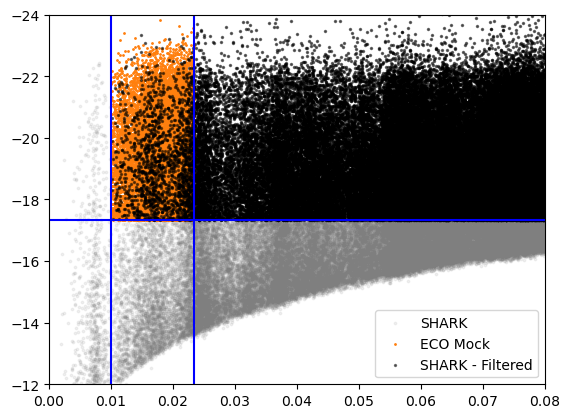

In [4]:
plt.figure()
plt.scatter(shark.redshift_observed, shark.mag_abs_r_SDSS, s=3, color='tab:gray', alpha=0.1, label='SHARK')
plt.scatter(m1.z, m1.M_r, s=1,color='tab:orange', label='ECO Mock')
plt.scatter(m2.redshift_observed, m2.mag_abs_r_SDSS, s=2, color='k', alpha=0.5, label='SHARK - Filtered')
plt.axhline(-17.33,color='blue')
plt.axvline(zmax,color='blue')
plt.axvline(zmin,color='blue')
plt.ylim(-12,-24)
plt.xlim(0,0.08)
plt.legend(loc='lower right')
plt.show()

# Footprint & Volume

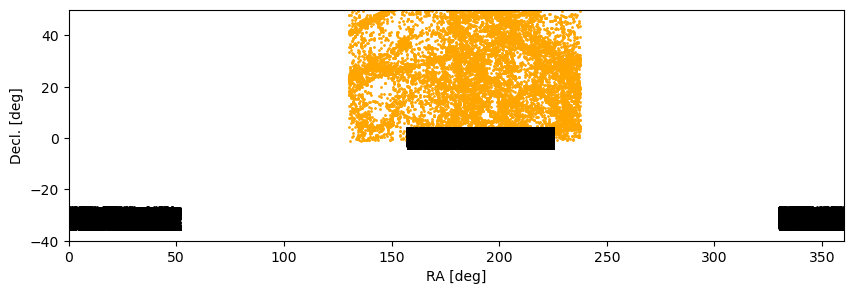

In [5]:
plt.figure(figsize=(10,3))
plt.scatter(m1.ra, m1.dec, color='orange', s=1)
plt.scatter(m2.ra, m2.dec, color='k', s=1)
plt.xlim(0,360)
plt.ylim(-40,50)
plt.xlabel("RA [deg]")
plt.ylabel("Decl. [deg]")
plt.show()

In [6]:
fp1 = m2[m2.footprint==1]
fp2 = m2[m2.footprint==2]
fp3 = m2[m2.footprint==3]
v1 = comoving_volume(fp1.ra.min(), fp1.ra.max(), fp1.dec.min(), fp1.dec.max(),\
                     fp1.redshift_observed.min(), fp1.redshift_observed.max(), 70, 0.3, 0.7)
v2 = comoving_volume(fp2.ra.min(), fp2.ra.max(), fp2.dec.min(), fp2.dec.max(),\
                     fp2.redshift_observed.min(), fp2.redshift_observed.max(), 70, 0.3, 0.7)
v3 = comoving_volume(fp3.ra.min(), fp3.ra.max(), fp3.dec.min(), fp3.dec.max(),\
                     fp3.redshift_observed.min(), fp3.redshift_observed.max(), 70, 0.3, 0.7)
m2vol = v1+v2+v3

m1vol = comoving_volume(m1.ra.min(), m1.ra.max(), m1.dec.min(), m1.dec.max(),\
                        m1.z.min(), m1.z.max(), 70, 0.3, 0.7)

print(f"ECO Mock Volume = {m1vol:0.5E} Mpc3")
print(f"SHARK Mock Volume = {m2vol:0.5E} Mpc3")
print(f"ECO/SHARK Vol Ratio = {m1vol/m2vol : 0.3f}")

ECO Mock Volume = 4.41402E+05 Mpc3
SHARK Mock Volume = 4.37074E+06 Mpc3
ECO/SHARK Vol Ratio =  0.101


# Number Density & Luminosity Function

In [7]:
m1ndens = len(m1) / m1vol
m2ndens = len(m2) / m2vol
print(f"ECO Mock n = {m1ndens:0.5f} Mpc-3")
print(f"SHARK Mock n = {m2ndens:0.5f} Mpc-3")
print(f"ECO-SHARK n ratio = {m1ndens/m2ndens : 0.2f}")

ECO Mock n = 0.04439 Mpc-3
SHARK Mock n = 0.01593 Mpc-3
ECO-SHARK n ratio =  2.79


In [8]:
Lbin = np.arange(-23,-17.33,0.5)
Lbinc = 0.5 * (Lbin[1:] + Lbin[:-1])
dL = Lbin[1]-Lbin[0] 
m1LF = np.histogram(m1.M_r, bins=Lbin)[0] / m1vol #/ dL
m2LF = np.histogram(m2.mag_abs_r_SDSS, bins=Lbin)[0] / m2vol #/ dL

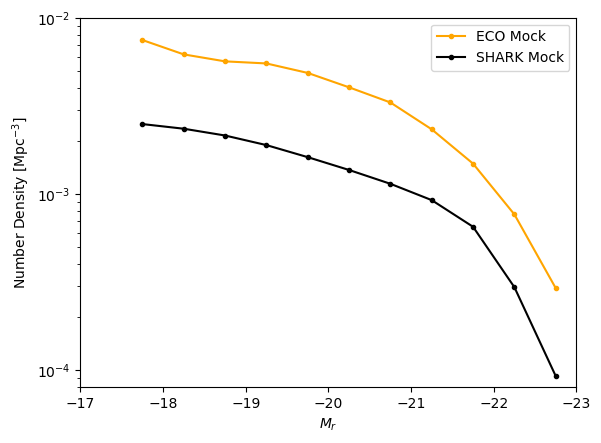

In [9]:
plt.figure()
plt.plot(Lbinc, m1LF, '.-', color='orange', label='ECO Mock')
plt.plot(Lbinc, m2LF, '.-', color='k', label='SHARK Mock')
plt.xlim(-17.,-23.)
plt.ylim(8e-5,1e-2)
plt.yscale('log')
plt.xlabel("$M_r$")
plt.ylabel("Number Density [Mpc$^{-3}$]")
plt.legend(loc='best')
plt.show()

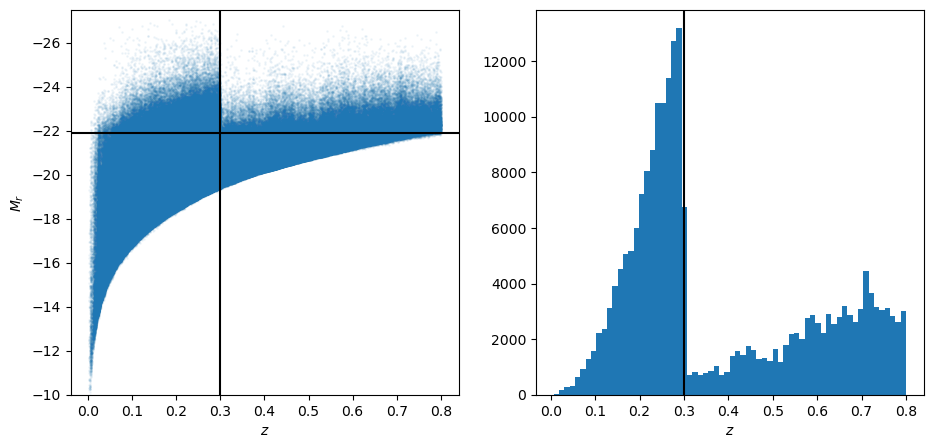

In [10]:
fig,axs=plt.subplots(ncols=2,figsize=(11,5))
axs[0].scatter(shark.redshift_observed, shark.mag_abs_r_SDSS, s=1, alpha=0.05)
axs[0].set_ylim(-10,-27.5)
axs[0].set_xlabel("$z$")
axs[0].set_ylabel(r'$M_r$')
axs[0].axhline(-21.9,color='k')
axs[0].axvline(0.3,color='k')

shark_complete = shark[shark.mag_abs_r_SDSS <= -21.9]
axs[1].hist(shark_complete.redshift_observed,bins='fd')
axs[1].axvline(0.3,color='k')
axs[1].set_xlabel('$z$')
plt.show()

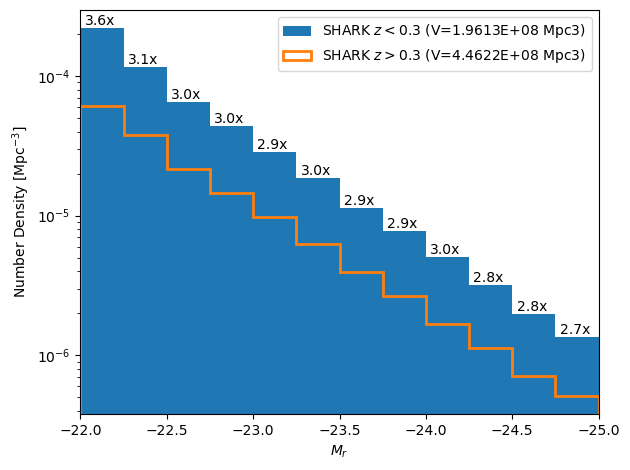

In [11]:
# Look at LF for z<0.3 and z>0.3 at -21.9
lowzsel = (shark_complete.redshift_observed <= 0.3)
shark_complete_lowz = shark_complete[lowzsel]
shark_complete_highz = shark_complete[~lowzsel]

#lowz vol
v1low = comoving_volume(fp1.ra.min(), fp1.ra.max(), fp1.dec.min(), fp1.dec.max(),\
                     0, 0.3, 70, 0.3, 0.7)
v2low = comoving_volume(fp2.ra.min(), fp2.ra.max(), fp2.dec.min(), fp2.dec.max(),\
                     0, 0.3, 70, 0.3, 0.7)
v3low = comoving_volume(fp3.ra.min(), fp3.ra.max(), fp3.dec.min(), fp3.dec.max(),\
                     0, 0.3, 70, 0.3, 0.7)
vlowtotal = v1low+v2low+v3low

#highz vol
v3high = comoving_volume(fp3.ra.min(), fp3.ra.max(), fp3.dec.min(), fp3.dec.max(),\
                     0.3, 0.8, 70, 0.3, 0.7)

Mrbin=np.arange(-25,-21.9,0.25)
Mrbinc = 0.5 * (Mrbin[1:] + Mrbin[:-1])
plt.figure()
hist_lowz,_,_=plt.hist(shark_complete_lowz.mag_abs_r_SDSS, bins=Mrbin, \
         weights=np.full(len(shark_complete_lowz),1/vlowtotal), label=f'SHARK $z<0.3$ (V={vlowtotal:0.4E} Mpc3)')
hist_highz,_,_=plt.hist(shark_complete_highz.mag_abs_r_SDSS, bins=Mrbin, \
         weights=np.full(len(shark_complete_highz),1/v3high), label=f'SHARK $z>0.3$ (V={v3high:0.4E} Mpc3)', histtype='step', linewidth=2)
excess=(hist_lowz / hist_highz)
labels = [f'{x:0.1f}x' for x in excess]
for i,l in enumerate(labels):
    plt.annotate(xy=(Mrbinc[i]+0.1,hist_lowz[i]*1.05), text=l)
plt.yscale('log')
plt.gca().invert_xaxis()
plt.xlabel("$M_r$")
plt.ylabel("Number Density [Mpc$^{-3}$]")
plt.xlim(-22,-25)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Group Multiplicity Function

In [12]:
m2.loc[:,'halo_ngal'] = multiplicity_function(m2.loc[:,'haloid'].to_numpy(),True)
m2.loc[:,'loghalom'] = np.log10(m2.loc[:,'mass_virial_hosthalo'])

/var/folders/8m/dhcvf5t90qb04kx2vn0wbvl00000gp/T/ipykernel_65500/1620560015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m2.loc[:,'halo_ngal'] = multiplicity_function(m2.loc[:,'haloid'].to_numpy(),True)
/var/folders/8m/dhcvf5t90qb04kx2vn0wbvl00000gp/T/ipykernel_65500/1620560015.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m2.loc[:,'loghalom'] = np.log10(m2.loc[:,'mass_virial_hosthalo'])


In [13]:
m1_halos = m1.groupby('haloid').first()
m2_halos = m2.groupby('haloid').first()

In [14]:
nbins=np.arange(0.5,300.5,1)
nbinc = 0.5 * (nbins[1:] + nbins[:-1])
m1_nN = np.histogram(m1_halos.halo_ngal, bins=nbins)[0] / m1vol
m2_nN = np.histogram(m2_halos.halo_ngal, bins=nbins)[0] / m2vol

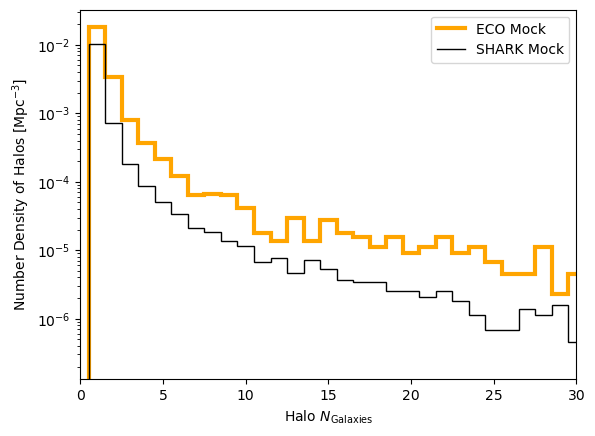

In [15]:
plt.figure()
plt.stairs(m1_nN, nbins, color='orange', linewidth=3, label='ECO Mock')
plt.stairs(m2_nN, nbins, color='k', label='SHARK Mock')
plt.yscale('log')
plt.xlim(0,30)
plt.legend(loc='upper right')
plt.xlabel(r'Halo $N_{\rm Galaxies}$')
plt.ylabel("Number Density of Halos [Mpc$^{-3}$]")
plt.show()

In [16]:
print(f"ECO Avg Density of Halos = {np.sum(m1_nN):0.4f} Mpc-3")
print(f"SHARK Avg Density of Halos = {np.sum(m2_nN):0.4f} Mpc-3")

ECO Avg Density of Halos = 0.0240 Mpc-3
SHARK Avg Density of Halos = 0.0116 Mpc-3


In [17]:
print(f"ECO Avg Density of N>=2 Halos = {np.sum(m1_nN[nbinc>=2]):0.4f} Mpc-3")
print(f"SHARK Avg Density of N>=2 Halos = {np.sum(m2_nN[nbinc>=2]):0.4f} Mpc-3")

ECO Avg Density of N>=2 Halos = 0.0055 Mpc-3
SHARK Avg Density of N>=2 Halos = 0.0012 Mpc-3


In [18]:
print(f"Largest ECO Group N = {m1.halo_ngal.max()}")
print(f"Largest SHARK Group N = {m2.halo_ngal.max()}")

Largest ECO Group N = 480
Largest SHARK Group N = 271


# Halo Mass Function

In [19]:
m1_logmh = m1_halos.loghalom.to_numpy()
m2_logmh = m2_halos.loghalom.to_numpy()

In [20]:
logMbins = np.arange(10,14.5,0.2)
logMbinc = 0.5 * (logMbins[:-1] + logMbins[1:])
dlogM = logMbins[1]-logMbins[0] 

In [21]:
m1_dndlogM = np.histogram(m1_logmh, bins=logMbins)[0] / m1vol / dlogM
m2_dndlogM = np.histogram(m2_logmh, bins=logMbins)[0] / m2vol / dlogM

m1_nc = np.cumsum(m1_dndlogM[::-1] * dlogM)[::-1]
m2_nc = np.cumsum(m2_dndlogM[::-1] * dlogM)[::-1]

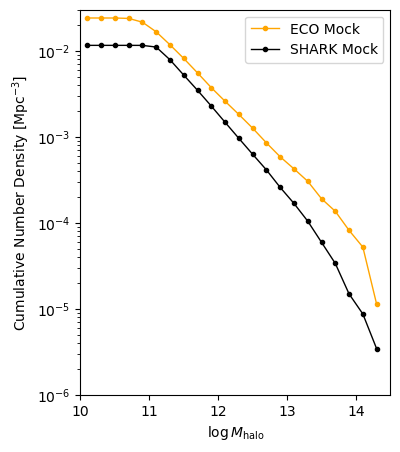

In [22]:
plt.figure(figsize=(4,5))
plt.plot(logMbinc, m1_nc, '.-',color='orange', linewidth=1, label='ECO Mock')
plt.plot(logMbinc, m2_nc, '.-',color='k', linewidth=1, label='SHARK Mock')
plt.ylim(1e-6,3e-2)
plt.yscale('log')
plt.xlim(10,14.5)
plt.xlabel(r"$\log M_{\rm halo}$")
plt.ylabel("Cumulative Number Density [Mpc$^{-3}$]")
plt.legend(loc='best')
plt.show()

# HOD

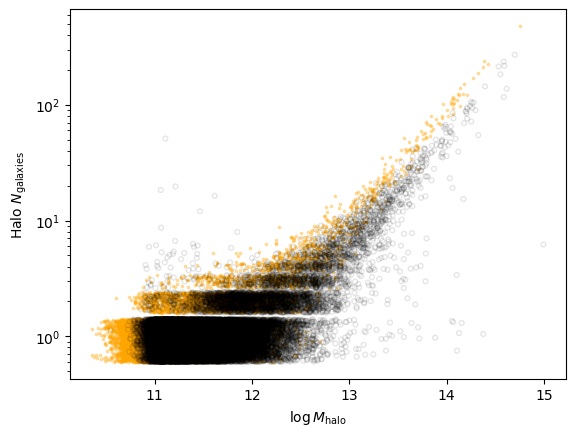

In [23]:
plt.figure()
jitter1 = np.random.uniform(-0.4,0.4,len(m1_halos))
jitter2 = np.random.uniform(-0.4,0.4,len(m2_halos))
plt.scatter(m1_halos.loghalom, m1_halos.halo_ngal+jitter1, color='orange', alpha=0.3,s=3)
plt.scatter(m2_halos.loghalom, m2_halos.halo_ngal+jitter2, facecolor='None', edgecolor='k', s=12, alpha=0.1)
plt.yscale('log')
plt.xlabel(r'$\log M_{\rm halo}$')
plt.ylabel(r'Halo $N_{\rm galaxies}$')
plt.show()

In [24]:
m1_Navg = binned_statistic(m1_halos.loghalom, m1_halos.halo_ngal, bins=logMbins)[0]
m2_Navg = binned_statistic(m2_halos.loghalom, m2_halos.halo_ngal, bins=logMbins)[0]

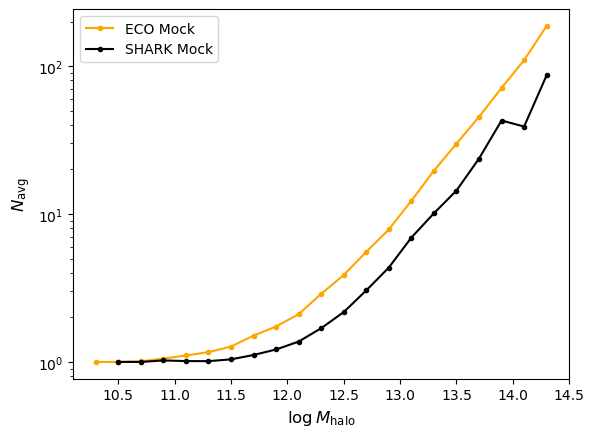

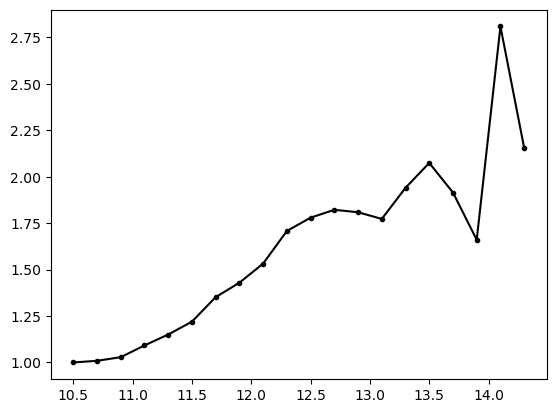

In [25]:
plt.figure()
plt.plot(logMbinc, m1_Navg, '.-', color='orange', label='ECO Mock')
plt.plot(logMbinc, m2_Navg, '.-', color='k', label='SHARK Mock')
plt.yscale('log')
plt.xlabel(r'$\log M_{\rm halo}$', fontsize=12)
plt.ylabel(r'$N_{\rm avg}$', fontsize=12)
plt.legend(loc='best')
plt.show()

plt.figure()
plt.plot(logMbinc, m1_Navg / m2_Navg, 'k.-')
plt.show()

# $R_{\rm proj,gal}$ and $\Delta v_{\rm proj,gal}$ Distributions

In [26]:
cosmo = LambdaCDM(70,0.3,0.7)

In [27]:
m1halora, m1halodec, m1haloz = group_skycoords(m1.ra, m1.dec, m1.z, m1.haloid)
m1_alpha_ij = angular_separation(m1.ra, m1.dec, m1halora, m1halodec)
m1_rprojgal = m1_alpha_ij * cosmo.comoving_transverse_distance(m1haloz)
m1_Dvprojgal = cc * np.abs(m1.z - m1haloz) / (1 + m1haloz)

In [28]:
m2halora, m2halodec, m2haloz = group_skycoords(m2.ra, m2.dec, m2.redshift_observed, m2.haloid)
m2_alpha_ij = angular_separation(m2.ra, m2.dec, m2halora, m2halodec)
m2_rprojgal = m2_alpha_ij * cosmo.comoving_transverse_distance(m2haloz)
m2_Dvprojgal = cc * np.abs(m2.redshift_observed - m2haloz) / (1 + m2haloz)

In [29]:
pt16 = lambda x: np.percentile(x,16)
pt84 = lambda x: np.percentile(x,84)

In [30]:
logMbins = np.arange(11,14.5,0.25)
logMbinc = 0.5 * (logMbins[1:] + logMbins[:-1])

In [31]:
m1_median_rprojgal = binned_statistic(m1.loghalom, m1_rprojgal, bins=logMbins, statistic='median')[0]
m1_pt16_rprojgal = binned_statistic(m1.loghalom, m1_rprojgal, bins=logMbins, statistic=pt16)[0]
m1_pt84_rprojgal = binned_statistic(m1.loghalom, m1_rprojgal, bins=logMbins, statistic=pt84)[0]

m1_median_Dvprojgal = binned_statistic(m1.loghalom, m1_Dvprojgal, bins=logMbins, statistic='median')[0]
m1_pt16_Dvprojgal = binned_statistic(m1.loghalom, m1_Dvprojgal, bins=logMbins, statistic=pt16)[0]
m1_pt84_Dvprojgal = binned_statistic(m1.loghalom, m1_Dvprojgal, bins=logMbins, statistic=pt84)[0]

In [32]:
m2_median_rprojgal = binned_statistic(m2.loghalom, m2_rprojgal, bins=logMbins, statistic='median')[0]
m2_pt16_rprojgal = binned_statistic(m2.loghalom, m2_rprojgal, bins=logMbins, statistic=pt16)[0]
m2_pt84_rprojgal = binned_statistic(m2.loghalom, m2_rprojgal, bins=logMbins, statistic=pt84)[0]

m2_median_Dvprojgal = binned_statistic(m2.loghalom, m2_Dvprojgal, bins=logMbins, statistic='median')[0]
m2_pt16_Dvprojgal = binned_statistic(m2.loghalom, m2_Dvprojgal, bins=logMbins, statistic=pt16)[0]
m2_pt84_Dvprojgal = binned_statistic(m2.loghalom, m2_Dvprojgal, bins=logMbins, statistic=pt84)[0]

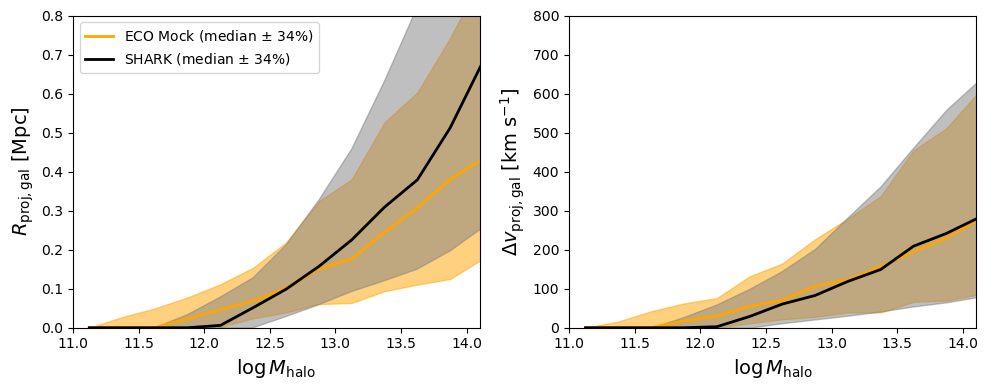

In [33]:
fig, axs = plt.subplots(ncols=2,figsize=(10,4))

axs[0].plot(logMbinc, m1_median_rprojgal, color='orange', linewidth=2, label=r'ECO Mock (median $\pm$ 34%)')
axs[0].fill_between(logMbinc, m1_pt16_rprojgal, m1_pt84_rprojgal, color='orange', alpha=0.5)
axs[0].plot(logMbinc, m2_median_rprojgal, color='k', linewidth=2, label=r'SHARK (median $\pm$ 34%)')
axs[0].fill_between(logMbinc, m2_pt16_rprojgal, m2_pt84_rprojgal, color='gray', alpha=0.5)

axs[1].plot(logMbinc, m1_median_Dvprojgal, color='orange', linewidth=2, label=r'ECO Mock (median $\pm$ 34%)')
axs[1].fill_between(logMbinc, m1_pt16_Dvprojgal, m1_pt84_Dvprojgal, color='orange', alpha=0.5)
axs[1].plot(logMbinc, m2_median_Dvprojgal, color='k', linewidth=2, label=r'SHARK (median $\pm$ 34%)')
axs[1].fill_between(logMbinc, m2_pt16_Dvprojgal, m2_pt84_Dvprojgal, color='gray', alpha=0.5)

axs[0].legend(loc='upper left')
axs[0].set_ylabel(r'$R_{\rm proj,gal}$ [Mpc]',fontsize=14)
axs[1].set_ylabel(r'$\Delta v_{\rm proj,gal}$ [km s$^{-1}$]',fontsize=14)
axs[0].set_ylim(0,0.8)
axs[1].set_ylim(0,800)
for ax in axs:
    ax.set_xlabel(r'$\log M_{\rm halo}$',fontsize=14)
    ax.set_xlim(11,14.1)
plt.tight_layout()
plt.show()

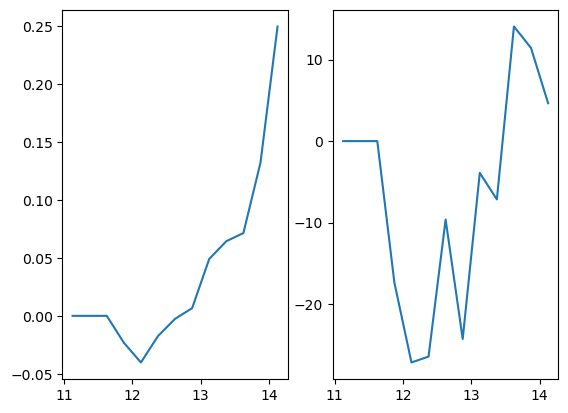

In [34]:
fig, axs=plt.subplots(ncols=2)
axs[0].plot(logMbinc, m2_median_rprojgal - m1_median_rprojgal)
axs[1].plot(logMbinc, m2_median_Dvprojgal - m1_median_Dvprojgal)

# $z_{\rm obs} - z_{\rm cos}$ Velocity Bias

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))

axs[0].scatter(m1.cz_nodist/cc, m1.cz/cc - m1.cz_nodist/cc, s=1, alpha=0.5)
axs[1].scatter(m2.redshift_cosmological, m2.redshift_observed-m2.redshift_cosmological, s=1, alpha=0.1)
print(np.median(m1.cz/cc - m1.cz_nodist/cc))
print(np.median(m2.redshift_observed-m2.redshift_cosmological))
plt.show()

In [ ]:
plt.figure()
plt.grid()
dz=m2.redshift_observed-m2.redshift_cosmological
median, bins, _ = binned_statistic(m2.redshift_cosmological, dz, bins=15, statistic='median')
plt.scatter(m2.redshift_cosmological, dz, s=1, alpha=0.1, label='median')
plt.plot(0.5*(bins[1:]+bins[:-1]), median, 'k.-')
plt.ylim(-0.005,0.005)
plt.ylabel(r'$z_{\rm obs}-z_{\rm cos}$',fontsize=14)
plt.xlabel(r'$z_{\rm cos}$',fontsize=14)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig("../figures/dz_m2.png")
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))

axs[0].scatter(m1.loghalom, m1.cz/cc - m1.cz_nodist/cc, s=1, alpha=0.5)
axs[1].scatter(m2.loghalom, m2.redshift_observed-m2.redshift_cosmological, s=1, alpha=0.1)
print(np.median(m1.cz/cc - m1.cz_nodist/cc))
print(np.median(m2.redshift_observed-m2.redshift_cosmological))
plt.show()